In [1]:
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


import Bio.Seq

import utils
utils.add_projects_to_path()
import protein_utils
from protein_utils.sequences.msa import get_msa_from_filename
from protein_utils.sequences.encoding import DEFAULT_ENCODER

In [2]:
msa = get_msa_from_filename("../data/sadA_clean.fasta")
weights = np.load("../data/sadA_clean.weights.npy")
assert(weights.shape[0] == msa.shape[0])
N_eff = weights.sum()
N_eff

879.0

In [3]:
q = 21
lam_pseudo = 1
msa_one_hot = np.eye(q)[msa]
msa_one_hot.shape

(879, 272, 21)

In [4]:
f_ia = (lam_pseudo / q +  np.einsum("n,nia->ia", weights, msa_one_hot) ) \
            / (lam_pseudo + N_eff) 
f_ia.shape

(272, 21)

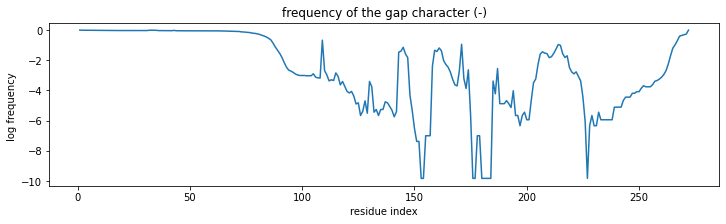

In [5]:
fig = plt.figure(figsize=(12, 3))
plt.plot(np.arange(1, f_ia.shape[0]+1), np.log(f_ia[:, 20]))
plt.title("frequency of the gap character (-)")
plt.xlabel("residue index")
plt.ylabel("log frequency ")
pass

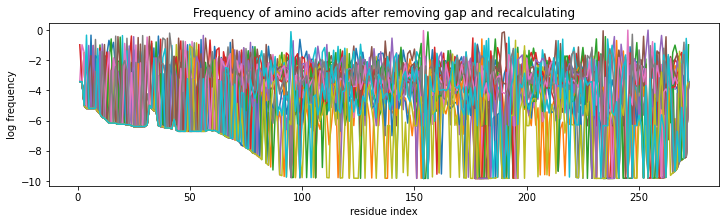

In [6]:
f_ia_nogap = f_ia[:, :20]  / f_ia[:, :20].sum(axis=1)[:, np.newaxis]
h_ia = np.log(f_ia_nogap)
fig = plt.figure(figsize=(12, 3))
plt.plot(np.arange(1, h_ia.shape[0]+1), h_ia)
plt.title("Frequency of amino acids after removing gap and recalculating")
plt.ylabel("log frequency")
plt.xlabel("residue index")
pass

In [7]:
model_seqs = pd.read_excel("../output/2D/azid_model_sequences.xlsx")
model_seqs.head()

,mutants_in_seq,category,count_frac_bin,mut_type,response,dist_parent
0,D65N;F152L,High Azidation,0.048529,beneficial,3,2
1,D65N;G192S,High Azidation,0.112263,NaN,3,2
2,NaN,High Azidation,0.109123,NaN,3,0
3,A211T;K227I,High Azidation,0.089621,NaN,3,2
4,D65N;F152L;K227I,High Azidation,0.088376,beneficial,3,3


In [8]:
parent_2d = str(Bio.SeqIO.read("../data/2D/2D.fasta", format="fasta").translate().seq)

In [9]:
parse_mutant = re.compile(r"^(?P<wtaa>[A-Z])(?P<idx>[0-9]*)(?P<mutaa>[A-Z])$")

def expand_mut_str_list(mut_str, ref, split_mut_char=";", offset=1):
    mut = list(str(parent_2d))
    if isinstance(mut_str, str) and len(mut_str) > 0: # if not we are going to return the reference
        for m in mut_str.split(split_mut_char):
            md = parse_mutant.match(m).groupdict()
            idx = int(md['idx'])
            assert(md['wtaa'] == mut[idx- offset])
            mut[idx - offset] = md['mutaa']
    return "".join(mut)

In [10]:
model_seqs["aa_seq"] = model_seqs.mutants_in_seq.map(
    lambda x: expand_mut_str_list(x, parent_2d, split_mut_char=";", offset=1))

model_seqs["aa_seq_trim"] = model_seqs.aa_seq.str.slice(1, -1)

model_seqs["pssm_score"] = model_seqs.aa_seq_trim.map(lambda x:
    h_ia[np.arange(h_ia.shape[0]), DEFAULT_ENCODER.string_to_np(x)].sum())

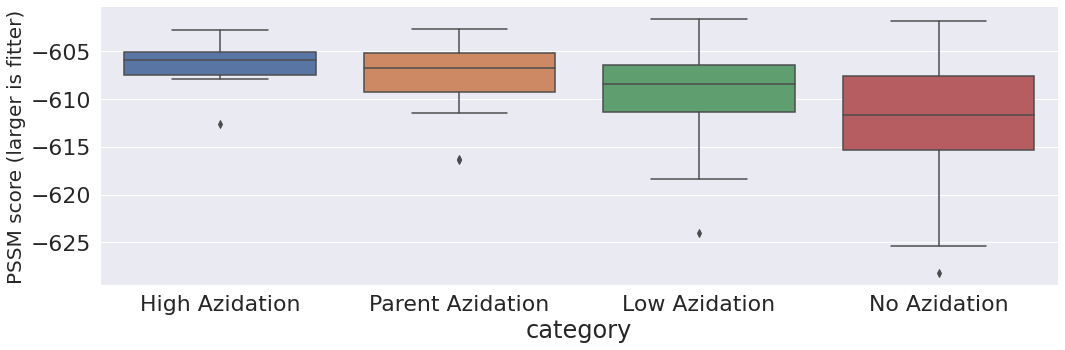

In [11]:
sns.set(font_scale=2)
g = sns.catplot(x='category', y='pssm_score', data=model_seqs, kind="box", aspect=3)
g.set_ylabels('PSSM score (larger is fitter)', fontsize=20)
pass